### Tratamento da Base de Dados

In [20]:
# notebook setup
# sys para interagir com o interpretador python
import sys
# pathlib facilita o trabalho com caminhos de arquivos e diretórios
from pathlib import Path

# adicionando a pasta raiz do projeto ao pythonpath
# permite a importação de módulos da pasta src
root_dir = Path().resolve().parent
sys.path.append(str(root_dir))

In [21]:
# imports 
# pandas para manipulação e análise de dados
import pandas as pd
# matplotlib para visualização de dados
import matplotlib.pyplot as plt
# funções de carregamento de dados e o caminho do dataset
from src.utils import load_data
from src.paths import raw_data_path 

In [22]:
# carregando a base de dados
df = load_data(raw_data_path)
# validação rápida do carregamento
df.head()

,Saiu_da_Empresa,Idade,Frequência de Viagens,Distância_do_trabalho,Formação,E-Sat,Gênero,Estado_Civil,Salário,Qte_Empresas_Trabalhadas,Faz_hora_extras?,Perc_de_aumento,Qte_ações_da_empresa,Tempo_de_carreira,Horas_de_treinamento,Equilibrio_de_Vida,Tempo_de_empresa,Anos_no_mesmo_cargo,Anos_desde_a_ultima_promocao,Anos_com_o_mesmo_chefe
0,Sim,41,Viaja raramente,1,Ensino Técnico,Médio,M,Solteiro,5993,8,Sim,11,0,8,0,Ruim,6,4,0,5
1,Não,49,Viaja frequentemente,8,Ensino Médio,Alto,H,Casado,5130,1,Não,23,1,10,3,Muito bom,10,7,1,7
2,Sim,37,Viaja raramente,2,Ensino Técnico,Muito Alto,H,Solteiro,2090,6,Sim,15,0,7,3,Muito bom,0,0,0,0
3,Não,33,Viaja frequentemente,3,Mestrado,Muito Alto,M,Casado,2909,1,Sim,11,0,8,3,Muito bom,8,7,3,0
4,Não,27,Viaja raramente,2,Ensino Médio,Baixo,H,Casado,3468,9,Não,12,1,6,3,Muito bom,2,2,2,2


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Saiu_da_Empresa               1470 non-null   object
 1   Idade                         1470 non-null   int64 
 2   Frequência de Viagens         1470 non-null   object
 3   Distância_do_trabalho         1470 non-null   int64 
 4   Formação                      1470 non-null   object
 5   E-Sat                         1470 non-null   object
 6   Gênero                        1470 non-null   object
 7   Estado_Civil                  1470 non-null   object
 8   Salário                       1470 non-null   int64 
 9   Qte_Empresas_Trabalhadas      1470 non-null   int64 
 10  Faz_hora_extras?              1470 non-null   object
 11  Perc_de_aumento               1470 non-null   int64 
 12  Qte_ações_da_empresa          1470 non-null   int64 
 13  Tempo_de_carreira 

In [24]:
df.columns

Index(['Saiu_da_Empresa', 'Idade', 'Frequência de Viagens',
       'Distância_do_trabalho', 'Formação', 'E-Sat', 'Gênero', 'Estado_Civil',
       'Salário', 'Qte_Empresas_Trabalhadas', 'Faz_hora_extras?',
       'Perc_de_aumento', 'Qte_ações_da_empresa', 'Tempo_de_carreira',
       'Horas_de_treinamento', 'Equilibrio_de_Vida', 'Tempo_de_empresa',
       'Anos_no_mesmo_cargo', 'Anos_desde_a_ultima_promocao',
       'Anos_com_o_mesmo_chefe'],
      dtype='object')

In [25]:
# padronização dos nomes das colunas
colunas = ['saiu_da_empresa', 'idade', 'frequencia_de_viagens',
       'distancia_do_trabalho', 'formacao', 'e-sat', 'genero', 'estado_civil',
       'salario', 'quantidade_de_empresas_trabalhadas', 'faz_hora_extra',
       'percentual_de_aumento', 'quantidade_de_acoes_da_empresa', 'tempo_de_carreira',
       'horas_de_treinamento', 'equilibrio_de_vida', 'tempo_de_empresa',
       'anos_no_mesmo_cargo', 'anos_desde_a_ultima_promocao',
       'anos_com_o_mesmo_chefe']
df.columns = colunas
df.columns

Index(['saiu_da_empresa', 'idade', 'frequencia_de_viagens',
       'distancia_do_trabalho', 'formacao', 'e-sat', 'genero', 'estado_civil',
       'salario', 'quantidade_de_empresas_trabalhadas', 'faz_hora_extra',
       'percentual_de_aumento', 'quantidade_de_acoes_da_empresa',
       'tempo_de_carreira', 'horas_de_treinamento', 'equilibrio_de_vida',
       'tempo_de_empresa', 'anos_no_mesmo_cargo',
       'anos_desde_a_ultima_promocao', 'anos_com_o_mesmo_chefe'],
      dtype='object')

In [26]:
# verificando valores nulos
df.isnull().sum()

saiu_da_empresa                       0
idade                                 0
frequencia_de_viagens                 0
distancia_do_trabalho                 0
formacao                              0
e-sat                                 0
genero                                0
estado_civil                          0
salario                               0
quantidade_de_empresas_trabalhadas    0
faz_hora_extra                        0
percentual_de_aumento                 0
quantidade_de_acoes_da_empresa        0
tempo_de_carreira                     0
horas_de_treinamento                  0
equilibrio_de_vida                    0
tempo_de_empresa                      0
anos_no_mesmo_cargo                   0
anos_desde_a_ultima_promocao          0
anos_com_o_mesmo_chefe                0
dtype: int64

In [27]:
# verificando a consistência entre variáveis de tempo
# 'anos no mesmo cargo' não pode ser maior que 'tempo de empresa'
inconsistencias = df[df['anos_no_mesmo_cargo'] > df['tempo_de_empresa']]
print(f"Registros inconsistentes (cargo > empresa): {len(inconsistencias)}")

# 'anos com o mesmo chefe' também não pode superar 'tempo de empresa'
inconsistencias2 = df[df['anos_com_o_mesmo_chefe'] > df['tempo_de_empresa']]
print(f"Registros inconsistentes (chefe > empresa): {len(inconsistencias2)}")

Registros inconsistentes (cargo > empresa): 0
Registros inconsistentes (chefe > empresa): 0


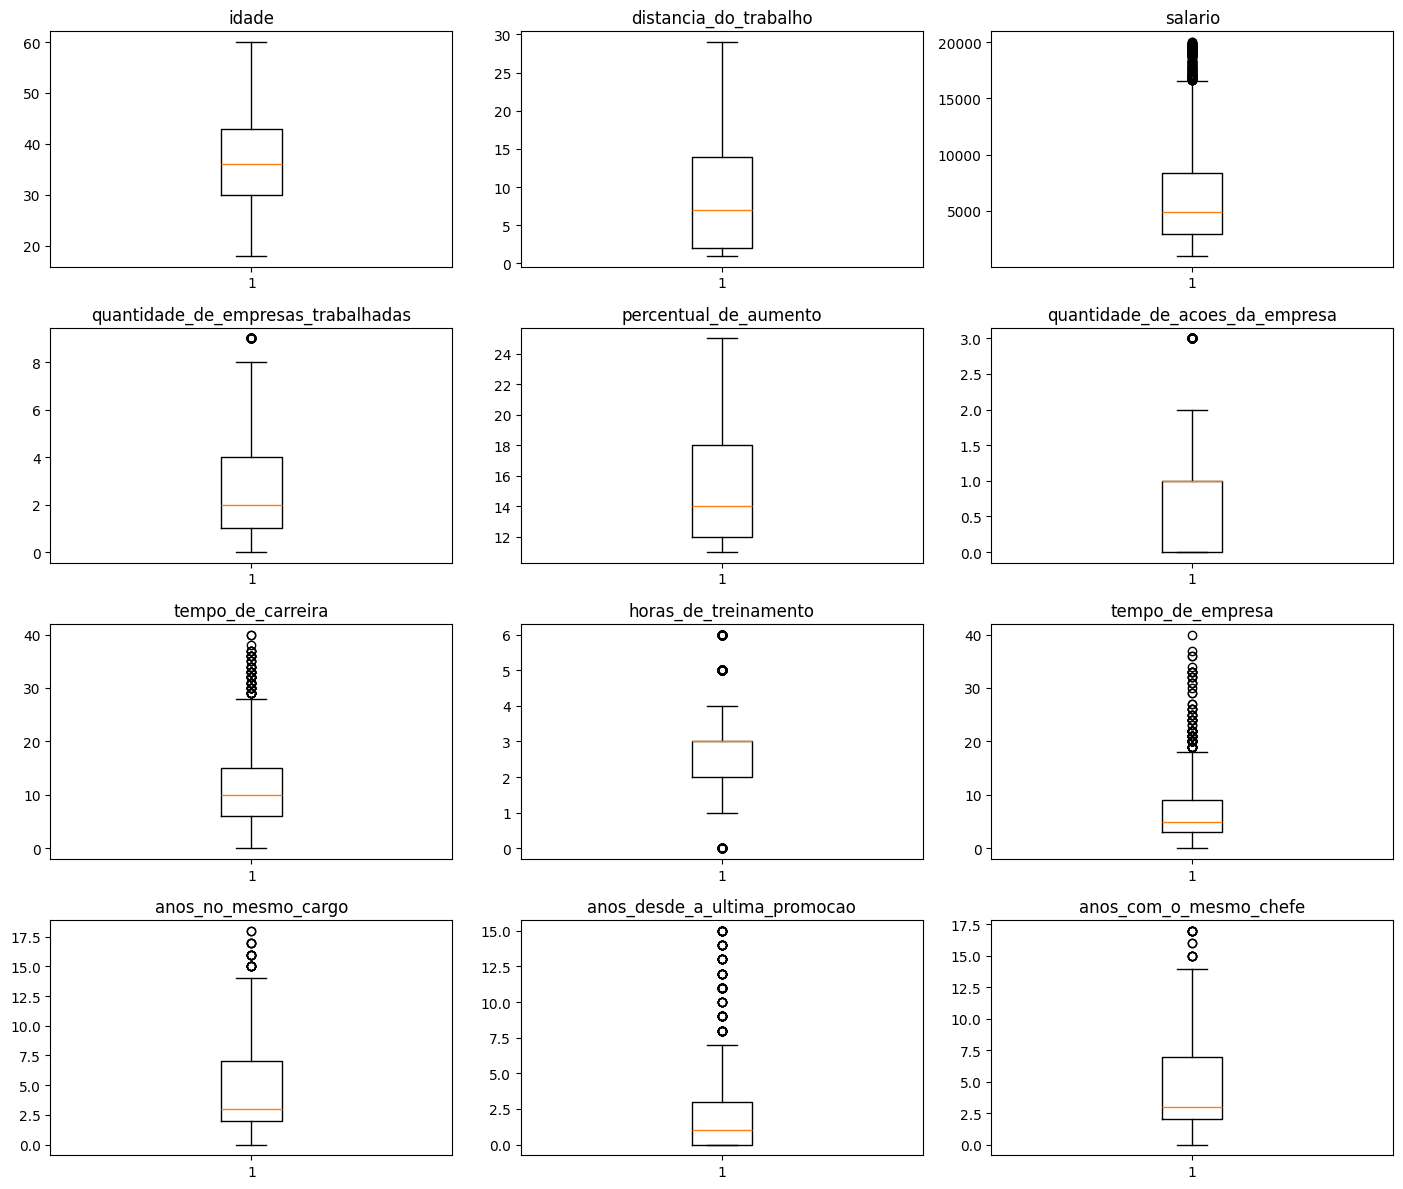

In [28]:
# análise de outliers nas variáveis numéricas
numericas = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

**Leitura da análise**

A análise de outliers indica que a maioria das variáveis numéricas apresenta 
distribuições sem pontos extremos problemáticos. Os valores atípicos observados 
em `salario`, `tempo de carreira` e `tempo de empresa` são esperados dado o contexto.

Merecem atenção os outliers em `anos desde a ultima promocao`, `anos no mesmo cargo` 
e `anos com o mesmo chefe`, que apresentam valores acima de 10–15 anos — incomuns 
e que podem indicar inconsistências na base ou casos muito específicos.

Como a base é fictícia e os valores não comprometem as análises exploratórias, 
optou-se por mantê-los sem remoção, registrando aqui a observação.

In [29]:
# salvando a base tratada
# criando a pasta processed caso não exista
processed_dir = root_dir / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

# caminho do arquivo tratado
processed_path = processed_dir / "base_rh_clean.csv"

# salvando o dataframe
df.to_csv(processed_path, sep=';', index=False)